# Asymmetric Stickyness in HMM-AR(1)

Investigates the case where transition probabilities are asymmetric:
- State 0: "normal" regime (low autocorrelation), high staying probability p00
- State 1: "episode" regime (high |autocorrelation|), lower staying probability p11

Key questions:
1. Does the HMM recover the asymmetric transition matrix?
2. Does interval score improve over AR(1) under asymmetry?
3. Does the direction of beta in the episode state matter (positive vs negative)?

## Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from methods.hmm_ar_1_k_states import simulate_rs_ar1
from methods.hmm_utils import (
    fit_single_ar1, predict_single_ar1,
    fit_hmm_robust, predict_hmm_hard, predict_hmm_mixture,
    evaluate_predictions
)
from methods.plotting import set_style

set_style()


## Single example: assymetric P

Normal state (0) is sticky, episode state (1) is short-lived.

In [20]:
T = 1000
beta_true = np.array([0.05, 0.85])   # low vs high autocorrelation
sigma_true = np.array([0.5, 1.5])

p00 = 0.97   # normal state: very sticky
p11 = 0.80   # episode state: short-lived

P_true = np.array([
    [p00,      1 - p00],
    [1 - p11,  p11    ]
])

y, states = simulate_rs_ar1(T=T, beta=beta_true, sigma=sigma_true, P=P_true, seed=42)

split = int(0.8 * T)
y_train, y_test = y[:split], y[split:]


## Does the model recover the asymmetric transition matrix?

In [21]:
_, params_hat = fit_hmm_robust(y_train, K=2, n_starts=10, seed=42)

print("True P:")
print(P_true)
print("\nEstimated P:")
print(params_hat["P"].round(3))
print("\nTrue beta:", beta_true)
print("Estimated beta:", params_hat["beta"].round(3))


True P:
[[0.97 0.03]
 [0.2  0.8 ]]

Estimated P:
[[0.819 0.181]
 [0.024 0.976]]

True beta: [0.05 0.85]
Estimated beta: [0.776 0.059]


## Prediction intervals: Single example

In [22]:
alpha_level = 0.05

rho_hat, sigma_hat = fit_single_ar1(y_train)

pred_mean_ar1, lower_ar1, upper_ar1 = predict_single_ar1(y_train, y_test, rho_hat, sigma_hat, alpha=alpha_level)
pred_mean_mix, lower_mix, upper_mix = predict_hmm_mixture(y_train, y_test, params_hat, alpha=alpha_level)

print("AR(1):", evaluate_predictions(y_test, pred_mean_ar1, lower_ar1, upper_ar1, alpha=alpha_level))
print("HMM mixture:", evaluate_predictions(y_test, pred_mean_mix, lower_mix, upper_mix, alpha=alpha_level))


AR(1): {'rmse': 0.7960552437498188, 'coverage': 0.935, 'avg_width': 3.097651347887376, 'interval_score': 4.6676896624128075}
HMM mixture: {'rmse': 0.7762264030457949, 'coverage': 0.96, 'avg_width': 2.8739001460521583, 'interval_score': 3.750362236937271}


The HMM recovers the asymmetric transition structure (up to label switching) and clearly outperforms AR(1) on interval score (3.75 vs 4.67), with better coverage and narrower intervals.


## Varying parameters (grid experiment)

Fix p00=0.97 and T=1000. Vary episode stickiness (p11) and episode AR coefficient (beta1),
including negative values. Evaluate interval score difference: AR(1) minus HMM mixture.


In [23]:
p11_vals   = [0.50, 0.65, 0.80, 0.90]
beta1_vals = [-0.85, -0.5, -0.2, 0.2, 0.5, 0.85]
p00        = 0.97
T          = 1000
n_rep      = 20
alpha_level = 0.05
sigma_true  = np.array([0.5, 1.5])
beta0       = 0.05

results = []

for p11 in p11_vals:
    P = np.array([[p00, 1 - p00], [1 - p11, p11]])
    for beta1 in beta1_vals:
        beta = np.array([beta0, beta1])
        for rep in range(n_rep):
            seed = rep * 1000 + int(p11 * 100) + int(abs(beta1) * 100)
            try:
                y, _ = simulate_rs_ar1(T=T, beta=beta, sigma=sigma_true, P=P, seed=seed)
                split = int(0.8 * T)
                y_train, y_test = y[:split], y[split:]

                rho_hat, sigma_hat = fit_single_ar1(y_train)
                pm_ar1, lo_ar1, hi_ar1 = predict_single_ar1(
                    y_train, y_test, rho_hat, sigma_hat, alpha=alpha_level
                )

                _, params_hat = fit_hmm_robust(y_train, K=2, n_starts=10, seed=seed)
                pm_mix, lo_mix, hi_mix = predict_hmm_mixture(
                    y_train, y_test, params_hat, alpha=alpha_level
                )

                results.append({
                    "p11": p11, "beta1": beta1, "rep": rep, "method": "AR1",
                    **evaluate_predictions(y_test, pm_ar1, lo_ar1, hi_ar1, alpha=alpha_level)
                })
                results.append({
                    "p11": p11, "beta1": beta1, "rep": rep, "method": "HMM_mixture",
                    **evaluate_predictions(y_test, pm_mix, lo_mix, hi_mix, alpha=alpha_level)
                })

            except Exception:
                pass

results_df = pd.DataFrame(results)


### Interval score difference heatmap


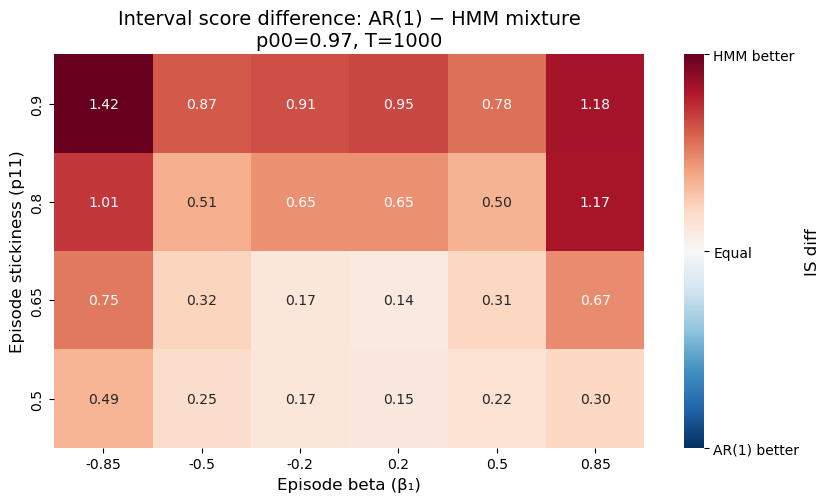

In [ ]:
summary_df = (
    results_df
    .groupby(["p11", "beta1", "method"], as_index=False)
    .agg(interval_score_mean=("interval_score", "mean"))
)

ar1_is = summary_df[summary_df["method"] == "AR1"][["p11", "beta1", "interval_score_mean"]].rename(
    columns={"interval_score_mean": "is_ar1"}
)
mix_is = summary_df[summary_df["method"] == "HMM_mixture"][["p11", "beta1", "interval_score_mean"]].rename(
    columns={"interval_score_mean": "is_mix"}
)

plot_df = ar1_is.merge(mix_is, on=["p11", "beta1"])
plot_df["is_diff"] = plot_df["is_ar1"] - plot_df["is_mix"]

pivot = plot_df.pivot(index="p11", columns="beta1", values="is_diff").sort_index(ascending=False)
max_abs = np.nanmax(np.abs(plot_df["is_diff"]))

fig, ax = plt.subplots(figsize=(9, 5))
hm = sns.heatmap(
    pivot, ax=ax, cmap="RdBu_r", vmin=-max_abs, vmax=max_abs,
    center=0, annot=True, fmt=".2f", square=True,
    cbar_kws={"label": "IS diff"}
)
cbar = hm.collections[0].colorbar
cbar.set_ticks([-max_abs, 0, max_abs])
cbar.set_ticklabels(["AR(1) better", "Equal", "HMM better"])
ax.set_title(f"Interval score difference: AR(1) − HMM mixture\np00={p00}, T={T}")
ax.set_xlabel(r"Episode $\phi$ ($\phi_1$)")
ax.set_ylabel("Episode stickiness (p11)")
plt.tight_layout()
plt.savefig("../plots/asym_is_diff_heatmap.pdf", bbox_inches="tight")
plt.show()


### Coverage and interval width


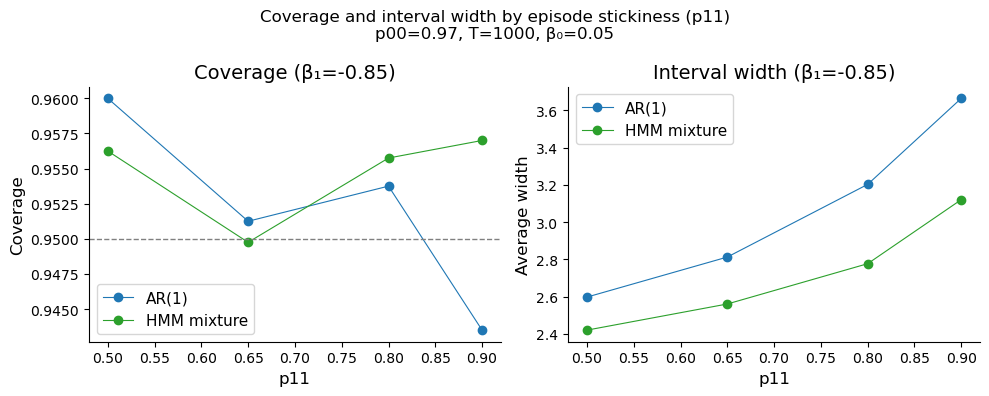

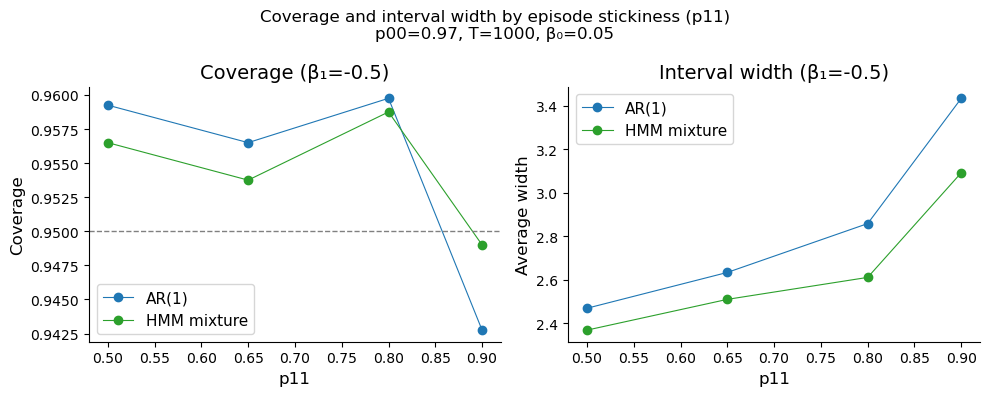

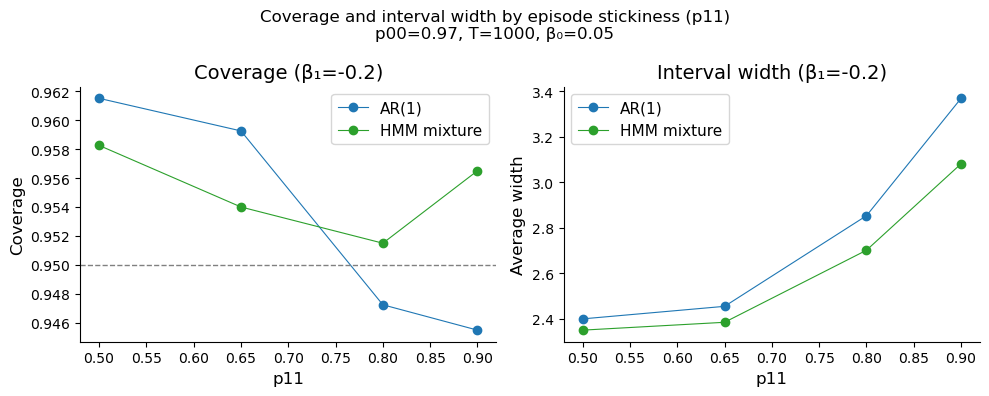

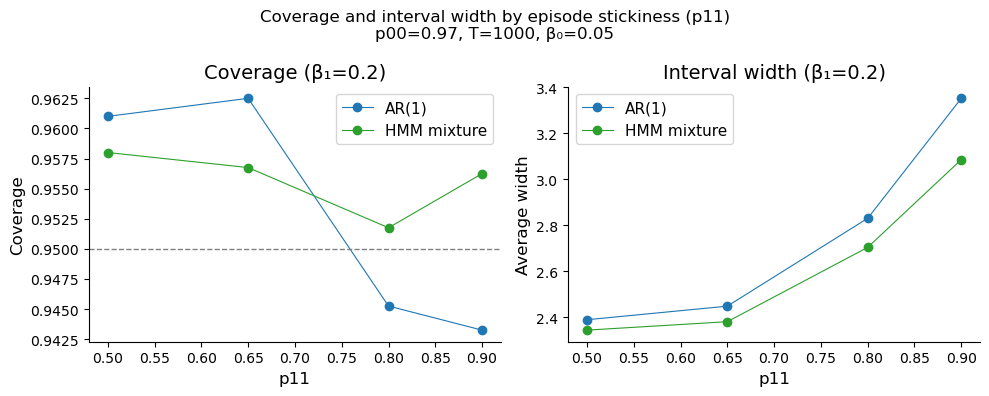

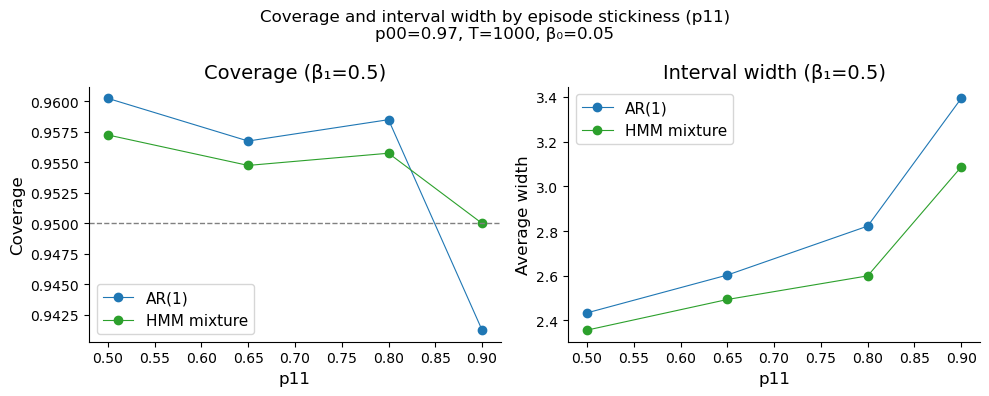

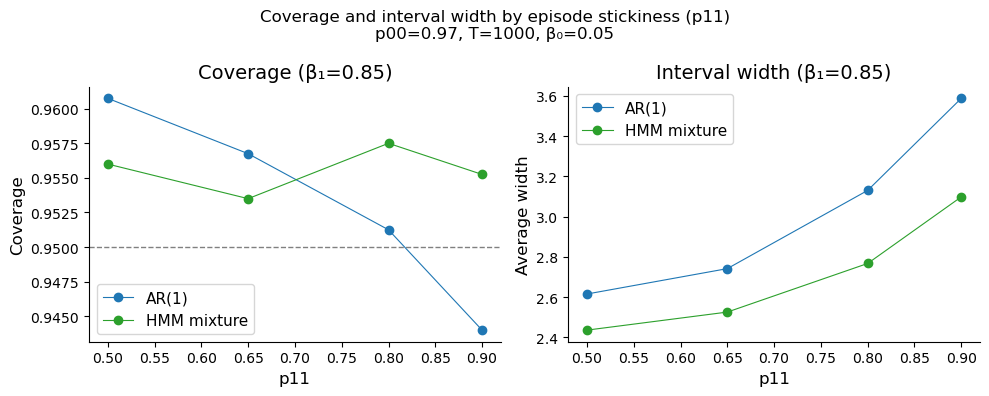

In [ ]:
summary_full = (
    results_df
    .groupby(["p11", "beta1", "method"], as_index=False)
    .agg(
        coverage_mean=("coverage", "mean"),
        avg_width_mean=("avg_width", "mean"),
    )
)

palette = {"AR1": "#1f77b4", "HMM_mixture": "#2ca02c"}
labels  = {"AR1": "AR(1)", "HMM_mixture": "HMM mixture"}

for beta1 in sorted(plot_df["beta1"].unique()):
    sub = summary_full[summary_full["beta1"] == beta1].sort_values("p11")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"Coverage and interval width by episode stickiness (p11)\np00={p00}, T={T}, $\\phi_0$={beta0}")



    for method in ["AR1", "HMM_mixture"]:
        tmp = sub[sub["method"] == method]
        axes[0].plot(tmp["p11"], tmp["coverage_mean"], marker="o",
                     label=labels[method], color=palette[method])
        axes[1].plot(tmp["p11"], tmp["avg_width_mean"], marker="o",
                     label=labels[method], color=palette[method])

    axes[0].axhline(0.95, linestyle="--", color="gray", linewidth=1)
    axes[0].set_title(f"Coverage ($\\phi_1$={beta1})")
    axes[0].set_xlabel("p11")
    axes[0].set_ylabel("Coverage")
    axes[0].legend()

    axes[1].set_title(f"Interval width ($\\phi_1$={beta1})")
    axes[1].set_xlabel("p11")
    axes[1].set_ylabel("Average width")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"../plots/asym_coverage_width_beta1_{str(beta1).replace('-','m')}.pdf", bbox_inches="tight")
    plt.show()


## Results

Across all values of β₁, HMM mixture consistently outperforms AR(1) on interval score.
The gain is driven by two effects visible in the coverage and width plots:

- **AR(1) under-covers at high p11**: as episodes grow longer and more distinct,
  AR(1)'s single estimated sigma becomes poorly calibrated — it is too narrow for
  episode periods and too wide for normal periods on average.
- **HMM mixture produces narrower intervals**: by weighting state-specific variances
  by filtered probabilities, the mixture adapts to the current regime.

The sign of β₁ does not matter — only the gap |β₁ − β₀| does. Negative and positive
episode betas give near-identical results, confirming that it is the magnitude of
regime separation, not its direction, that drives the gain.

Episode stickiness (p11) has a larger effect than the beta gap: even a small gap
(|β₁|=0.2) yields clear HMM gains at p11=0.90, while a large gap (|β₁|=0.85) gives
only modest gains at p11=0.50 where episodes average just 2 observations.
